In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import cv2
import random
import shutil
import albumentations as A

In [5]:
train_images_dir = "/content/drive/MyDrive/Annotated Dataset/train/images"
train_labels_dir = "/content/drive/MyDrive/Annotated Dataset/train/labels"

aug_images_dir = "/content/drive/MyDrive/Data Augmentation/train/images"
aug_labels_dir = "/content/drive/MyDrive/Data Augmentation/train/labels"

os.makedirs(aug_images_dir, exist_ok=True)
os.makedirs(aug_labels_dir, exist_ok=True)

In [6]:
for file in os.listdir(train_images_dir):
    shutil.copy(os.path.join(train_images_dir, file), aug_images_dir)

for file in os.listdir(train_labels_dir):
    shutil.copy(os.path.join(train_labels_dir, file), aug_labels_dir)

In [19]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Affine(
        translate_percent=0.05,
        scale=(0.9, 1.1),
        rotate=(-10, 10),
        p=0.5
    )
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels']
))

In [20]:
def read_yolo_labels(label_path):
    boxes = []
    class_labels = []

    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            class_id = int(parts[0])
            bbox = list(map(float, parts[1:]))

            class_labels.append(class_id)
            boxes.append(bbox)

    return boxes, class_labels

In [21]:
def save_yolo_labels(label_path, boxes, class_labels):
    with open(label_path, 'w') as f:
        for cls, box in zip(class_labels, boxes):
            f.write(f"{cls} {' '.join(map(str, box))}\n")

In [22]:
for image_file in os.listdir(train_images_dir):

    if not image_file.endswith(('.jpg', '.png', '.jpeg')):
        continue

    image_path = os.path.join(train_images_dir, image_file)
    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(train_labels_dir, label_file)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes, class_labels = read_yolo_labels(label_path)

    for i in range(1):  # Number of augmentations per image
        augmented = transform(
            image=image,
            bboxes=boxes,
            class_labels=class_labels
        )

        aug_image = augmented['image']
        aug_boxes = augmented['bboxes']
        aug_classes = augmented['class_labels']

        new_image_name = f"aug_{i}_{image_file}"
        new_label_name = f"aug_{i}_{label_file}"

        cv2.imwrite(
            os.path.join(aug_images_dir, new_image_name),
            cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
        )

        save_yolo_labels(
            os.path.join(aug_labels_dir, new_label_name),
            aug_boxes,
            aug_classes
        )

In [14]:
import cv2
import matplotlib.pyplot as plt

def read_yolo_labels(label_path):
    boxes = []
    classes = []
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])
            boxes.append([x, y, w, h])
            classes.append(cls)
    return boxes, classes

In [15]:
def draw_boxes(image_path, label_path, class_names):
    image = cv2.imread(image_path)
    h, w = image.shape[:2]
    boxes, classes = read_yolo_labels(label_path)

    for box, cls in zip(boxes, classes):
        x, y, bw, bh = box
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(image, class_names[cls], (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


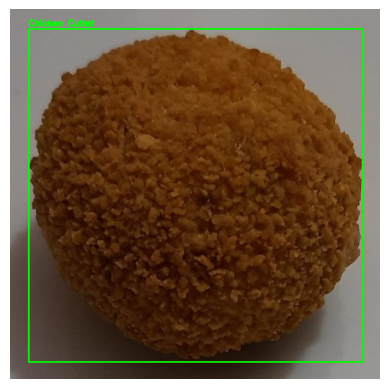

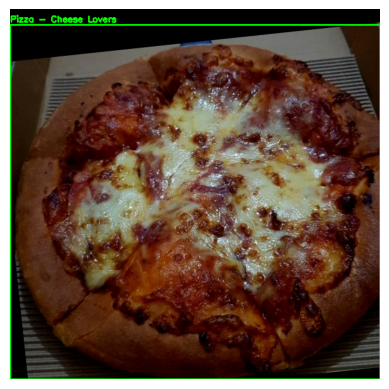

In [24]:
class_names = ["Chicken Bun","Chicken Cutlet","Chicken Pastry",
               "Chicken Rolls","Chicken Rotti",
               "Iced Coffee","Milk Rice","Pizza - Cheese Lovers"]

draw_boxes(
    "/content/drive/MyDrive/Data Augmentation/train/images/aug_0_27.jpg",
    "/content/drive/MyDrive/Data Augmentation/train/labels/aug_0_27.txt",
    class_names
)
draw_boxes(
    "/content/drive/MyDrive/Data Augmentation/train/images/aug_0_11.jpg",
    "/content/drive/MyDrive/Data Augmentation/train/labels/aug_0_11.txt",
    class_names
)
